# Classifier Guidance for Pixel Diffusion

This notebook extends `pixel_diffusion.ipynb`. It keeps the MNIST pixel diffusion U-Net noise predictor, then adds a noisy-image classifier. During sampling, the classifier gradient is injected so generation can be guided toward a target digit class.


## 1. Imports and configuration

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image
from tqdm import tqdm

# Keep this False if MNIST already exists in ./data, matching pixel_diffusion.ipynb.
# Change to True only when you want torchvision to download the dataset.
download_mnist = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


## 2. Time embedding and U-Net noise predictor

This section follows the original notebook idea: the U-Net receives a noisy image `x_t` and timestep `t`, then predicts the Gaussian noise that was added.


In [2]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=1)


class Block(nn.Module):
    def __init__(self, dim, dim_out, time_emb):
        super().__init__()
        self.conv1 = nn.Conv2d(dim, dim_out, 3, padding=1)
        self.conv2 = nn.Conv2d(dim_out, dim_out, 3, padding=1)
        self.time_mlp = nn.Linear(time_emb, dim_out)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb):
        h = F.relu(self.conv1(x))
        time_feature = self.time_mlp(time_emb)
        h = h + time_feature[:, :, None, None]
        h = F.relu(self.conv2(h))
        return h + self.res_conv(x)


class Unet(nn.Module):
    def __init__(self, in_ch=1, base_ch=64, time_emb=128):
        super().__init__()
        self.time_embed = nn.Sequential(
            TimeEmbedding(time_emb),
            nn.ReLU(),
        )
        self.down1 = Block(in_ch, base_ch, time_emb)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = Block(base_ch, base_ch * 2, time_emb)
        self.pool2 = nn.MaxPool2d(2)
        self.mid = Block(base_ch * 2, base_ch * 4, time_emb)
        self.up1 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec1 = Block(base_ch * 4, base_ch * 2, time_emb)
        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec2 = Block(base_ch * 2, base_ch, time_emb)
        self.out = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        x1 = self.down1(x, t_emb)
        x2 = self.pool1(x1)
        x3 = self.down2(x2, t_emb)
        x4 = self.pool2(x3)
        xm = self.mid(x4, t_emb)
        u1 = self.up1(xm)
        u1 = torch.cat([u1, x3], dim=1)
        u1 = self.dec1(u1, t_emb)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, x1], dim=1)
        u2 = self.dec2(u2, t_emb)
        return self.out(u2)


## 3. Diffusion utilities

In [3]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, T)


def q_sample(x0, t, alpha_bars, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    a_bar = alpha_bars[t].view(-1, 1, 1, 1).to(x0.device)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise


T = 100
betas = linear_beta_schedule(T).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0).to(device)


## 4. MNIST data

In [4]:
image_size = 28
image_channels = 1
batch_size = 128

tf = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="data", train=True, transform=tf, download=download_mnist)
test_dataset = datasets.MNIST(root="data", train=False, transform=tf, download=download_mnist)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"MNIST train samples: {len(train_dataset)}")
print(f"MNIST test samples: {len(test_dataset)}")


MNIST train samples: 60000
MNIST test samples: 10000


## 5. Load or train the diffusion model

If `mnist_diffusion.pth` already exists in this folder, the notebook loads the U-Net trained by the original notebook. If it does not exist, this cell trains a new diffusion model.


In [5]:
def load_state_dict_safely(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


diffusion_path = Path("mnist_diffusion.pth")
model = Unet(in_ch=image_channels, base_ch=64, time_emb=128).to(device)

if diffusion_path.exists():
    model.load_state_dict(load_state_dict_safely(diffusion_path, device))
    print(f"Loaded diffusion model from {diffusion_path}")
else:
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    epochs = 5

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x0, _ in tqdm(train_loader, desc=f"Diffusion epoch {epoch + 1}/{epochs}"):
            x0 = x0.to(device)
            b = x0.size(0)
            t = torch.randint(0, T, (b,), device=device)
            noise = torch.randn_like(x0)
            xt = q_sample(x0, t, alpha_bars, noise)
            pred_noise = model(xt, t)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"epoch {epoch + 1}, diffusion loss = {total_loss / len(train_loader):.4f}")

    torch.save(model.state_dict(), diffusion_path)
    print(f"Saved diffusion model to {diffusion_path}")


Loaded diffusion model from mnist_diffusion.pth


## 6. Noisy-image classifier

This classifier is trained on noisy MNIST images from random diffusion timesteps. That makes its gradient useful during sampling, including at noisier reverse-diffusion steps.


In [6]:
class NoisyMNISTClassifier(nn.Module):
    def __init__(self, time_emb=128, num_classes=10):
        super().__init__()
        self.time_embed = nn.Sequential(
            TimeEmbedding(time_emb),
            nn.Linear(time_emb, time_emb),
            nn.ReLU(),
        )
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.time_to_channels = nn.Linear(time_emb, 128)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, t):
        h = F.relu(self.conv1(x))
        h = self.pool(h)
        h = F.relu(self.conv2(h))
        h = self.pool(h)
        h = F.relu(self.conv3(h))
        t_emb = self.time_embed(t)
        h = h + self.time_to_channels(t_emb)[:, :, None, None]
        return self.head(h)


## 7. Train or load the classifier

In [7]:
classifier_path = Path("mnist_noisy_classifier.pth")
classifier = NoisyMNISTClassifier(time_emb=128).to(device)

if classifier_path.exists():
    classifier.load_state_dict(load_state_dict_safely(classifier_path, device))
    print(f"Loaded classifier from {classifier_path}")
else:
    classifier_optimizer = optim.Adam(classifier.parameters(), lr=1e-3)
    classifier_epochs = 3

    for epoch in range(classifier_epochs):
        classifier.train()
        total_loss = 0.0
        total_correct = 0
        total_seen = 0

        for x0, y in tqdm(train_loader, desc=f"Classifier epoch {epoch + 1}/{classifier_epochs}"):
            x0 = x0.to(device)
            y = y.to(device)
            b = x0.size(0)
            t = torch.randint(0, T, (b,), device=device)
            xt = q_sample(x0, t, alpha_bars)

            logits = classifier(xt, t)
            loss = F.cross_entropy(logits, y)

            classifier_optimizer.zero_grad()
            loss.backward()
            classifier_optimizer.step()

            total_loss += loss.item()
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_seen += b

        avg_loss = total_loss / len(train_loader)
        acc = total_correct / total_seen
        print(f"epoch {epoch + 1}, classifier loss = {avg_loss:.4f}, acc = {acc:.4f}")

    torch.save(classifier.state_dict(), classifier_path)
    print(f"Saved classifier to {classifier_path}")


Classifier epoch 1/3: 100%|██████████| 469/469 [00:06<00:00, 71.03it/s]


epoch 1, classifier loss = 1.6963, acc = 0.4040


Classifier epoch 2/3: 100%|██████████| 469/469 [00:06<00:00, 70.53it/s]


epoch 2, classifier loss = 0.7838, acc = 0.7455


Classifier epoch 3/3: 100%|██████████| 469/469 [00:08<00:00, 58.57it/s]

epoch 3, classifier loss = 0.6061, acc = 0.8043
Saved classifier to mnist_noisy_classifier.pth


## 8. Quick classifier check

In [8]:
classifier.eval()
total_correct = 0
total_seen = 0

with torch.no_grad():
    for x0, y in test_loader:
        x0 = x0.to(device)
        y = y.to(device)
        b = x0.size(0)
        # Evaluate at a middle noise level. You can try t=0, 25, 50, 75.
        t = torch.full((b,), 50, device=device, dtype=torch.long)
        xt = q_sample(x0, t, alpha_bars)
        logits = classifier(xt, t)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_seen += b

print(f"classifier acc at t=50: {total_correct / total_seen:.4f}")


classifier acc at t=50: 0.8710


## 9. Classifier-guided sampling

The injection point is `classifier_cond_grad`: it computes the gradient of `log p(y | x_t)` with respect to `x_t` for the target class. The reverse diffusion mean is then nudged by that gradient. Larger `guidance_scale` usually follows the target class more strongly, but too large a value can make images noisy or distorted.


In [ ]:
def classifier_cond_grad(classifier, xt, t, target_labels):
    classifier.eval()
    x_in = xt.detach().requires_grad_(True)#xt 被當成新的起點
    logits = classifier(x_in, t)
    log_probs = F.log_softmax(logits, dim=1)
    selected = log_probs[torch.arange(x_in.size(0), device=x_in.device), target_labels]
    grad = torch.autograd.grad(selected.sum(), x_in)[0]
    return grad


def guided_p_sample(
    model,
    classifier,
    xt,
    t,
    target_labels,
    betas,
    alphas,
    alpha_bars,
    guidance_scale=2.0,
):
    beta_t = betas[t].view(-1, 1, 1, 1)#ｔ　是ｔｉｍｅ　ｓｔｅｐ，ｂｅｔａ　ｔ　是對應的噪聲強度
    alpha_t = alphas[t].view(-1, 1, 1, 1)#ｔ　是ｔｉｍｅ　ｓｔｅｐ，ａｌｐｈａ　ｔ　是對應的信號強度
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)#ｔ　是ｔｉｍｅ　ｓｔｅｐ，ａｌｐｈａ　ｂａｒ　ｔ　是對應的累積信號強度

    with torch.no_grad():
        pred_noise = model(xt, t)
        mean = (xt - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * pred_noise) / torch.sqrt(alpha_t)
        # mean 是根據模型預測的噪聲來計算的，表示在當前時間步 t 下，從 xt 回推到 xt-1 的均值。
    if guidance_scale != 0:
        grad = classifier_cond_grad(classifier, xt, t, target_labels)
        mean = mean + guidance_scale * beta_t * grad

    noise = torch.randn_like(xt) #noise 是隨機噪聲，用於在回推過程中引入隨機性，從而生成多樣化的樣本。
    nonzero_mask = (t > 0).float().view(-1, 1, 1, 1)
    return mean + nonzero_mask * torch.sqrt(beta_t) * noise


def sample_class_guided(
    model,
    classifier,
    target_digits,
    image_size,
    device,
    betas,
    alphas,
    alpha_bars,
    image_channels=1,
    guidance_scale=2.0,
    capture_steps=None,
):
    model.eval()
    classifier.eval()
    target_labels = torch.tensor(target_digits, device=device, dtype=torch.long)
    n_samples = len(target_digits)
    xt = torch.randn(n_samples, image_channels, image_size, image_size, device=device)
    history = {"noise": xt.detach().cpu()}
    capture_steps = set(capture_steps or [])

    for step in tqdm(reversed(range(len(betas))), total=len(betas), desc="Guided sampling"):
        t = torch.full((n_samples,), step, device=device, dtype=torch.long)
        xt = guided_p_sample(
            model=model,
            classifier=classifier,
            xt=xt,
            t=t,
            target_labels=target_labels,
            betas=betas,
            alphas=alphas,
            alpha_bars=alpha_bars,
            guidance_scale=guidance_scale,
        )
        if step in capture_steps:
            history[f"t={step}"] = xt.detach().cpu().clamp(0, 1)

    xt = xt.clamp(0, 1)
    history["final"] = xt.detach().cpu()
    return xt, history


## 10. Generate digits by injecting the classifier

Guided sampling: 100%|██████████| 100/100 [00:00<00:00, 142.49it/s]


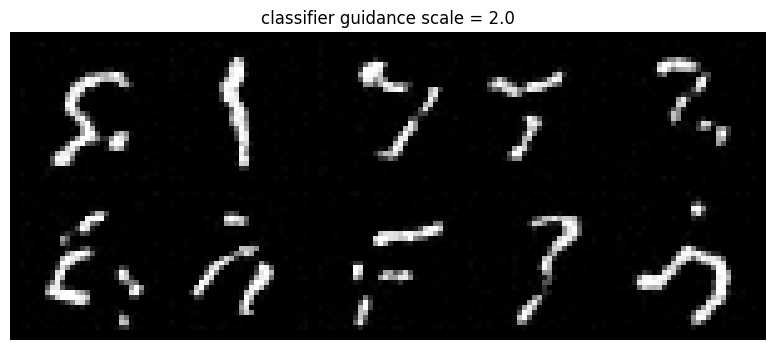

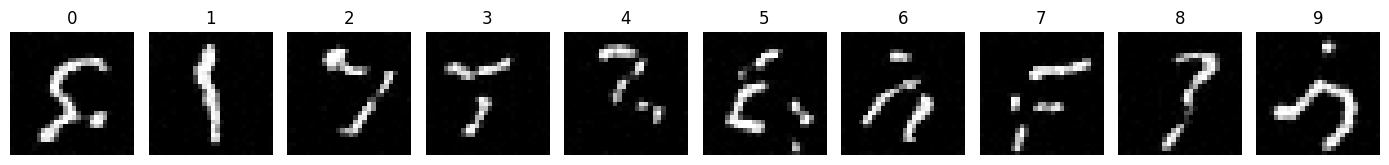

In [22]:
target_digits = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
guidance_scale = 2.0

samples, history = sample_class_guided(
    model=model,
    classifier=classifier,
    target_digits=target_digits,
    image_size=image_size,
    device=device,
    betas=betas,
    alphas=alphas,
    alpha_bars=alpha_bars,
    image_channels=image_channels,
    guidance_scale=guidance_scale,
    capture_steps=[75, 50, 25, 0],
)

save_image(samples, "mnist_classifier_guided_samples.png", nrow=5)

grid = make_grid(samples, nrow=5)
plt.figure(figsize=(10, 4))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray", vmin=0, vmax=1)
plt.title(f"classifier guidance scale = {guidance_scale}")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(1, len(target_digits), figsize=(14, 2))
for ax, digit, image in zip(axes, target_digits, samples.detach().cpu()):
    ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(str(digit))
    ax.axis("off")
plt.tight_layout()
plt.show()


## 11. Compare different guidance scales

Guided sampling: 100%|██████████| 100/100 [00:00<00:00, 195.86it/s]


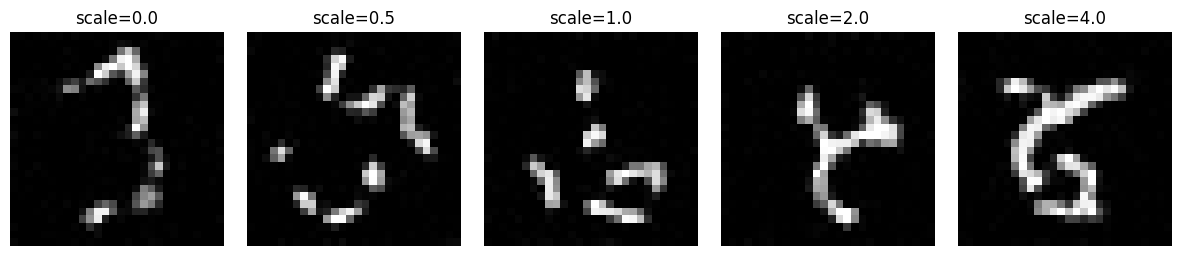

In [14]:
compare_digit = 8
scales = [0.0, 0.5, 1.0, 2.0, 4.0]
all_samples = []

for scale in scales:
    sample, _ = sample_class_guided(
        model=model,
        classifier=classifier,
        target_digits=[compare_digit],
        image_size=image_size,
        device=device,
        betas=betas,
        alphas=alphas,
        alpha_bars=alpha_bars,
        image_channels=image_channels,
        guidance_scale=scale,
    )
    all_samples.append(sample.cpu())

fig, axes = plt.subplots(1, len(scales), figsize=(12, 2.5))
for ax, scale, image in zip(axes, scales, torch.cat(all_samples, dim=0)):
    ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"scale={scale}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Notes

- `guidance_scale = 0` means no classifier guidance.
- If the target class is unclear, first check that the noisy classifier accuracy at `t=50` or `t=75` is reasonable.
- If images become broken or dirty, `guidance_scale` is probably too large. Try `0.5`, `1.0`, or `2.0` first.
- This is sampling-time classifier guidance, so the U-Net does not need to be retrained.
